## construct difference maps of left vs. right measure 

* on surface data

In [32]:

import matplotlib as mpl
#import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
#import torch
import os.path as op
import nibabel as nib
import nilearn.plotting as nplt

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
base = 'derivatives/encoding_model.smoothed'

cmap = 'RdBu'



### Transforming r2 maps from volume to surf space

#### Freesurfer Transformations & Registration files
* first specify the SUBJECTS_DIR= # instead of /Applications/freesurfer/7.2.0/subjects
* sub=02
* generate register.dat:  
    * `bbregister --s sub-${sub} --bold --mov /Volumes/mrenkeED/data/ds-stressrisk/derivatives/fmriprep/sub-${sub}/ses-1/func/sub-${sub}_ses-1_task-risk_run-1_space-T1w_boldref.nii.gz --reg /Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-${sub}/register_boldref_run-1.dat` with bold
    * check: `tkregisterfv --mov /Volumes/mrenkeED/data/ds-stressrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-preproc_T1w.nii.gz --reg /Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-${sub}/register.dat --surfs  --sd /Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer`

* transform:   
* *  bold: `for hemi in rh lh; do mri_vol2surf --mov encoding_model.smoothed/sub-${sub}/ses-1/func/sub-${sub}_ses-1_desc-r2.optim_space-T1w_pars.nii.gz --reg freesurfer/sub-${sub}/register_boldref_run-1.dat --hemi $hemi --o encoding_model.smoothed/sub-${sub}/ses-1/func/sub-${sub}_ses-1_desc-r2.optim_space-fsaverage5_pars_hemi-${hemi}.gii --trgsubject fsaverage5; done`

* old:
* * tried via mni space (does not need register.dat, cause transformation is known: `--mni152reg` option for mri_vol2surf)
* * register with normal T1 :
* * * `bbregister --s sub-${sub} --t1 --mov /Volumes/mrenkeED/data/ds-stressrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-preproc_T1w.nii.gz  --reg register.dat` 
* * * `mri_vol2surf --mov encoding_model.smoothed/sub-${sub}/ses-1/func/sub-${sub}_ses-1_desc-r2.optim_space-T1w_pars.nii.gz --reg freesurfer/sub-${sub}/register.dat --hemi rh --o encoding_model.smoothed/sub-${sub}/ses-1/func/sub-${sub}_ses-1_desc-r2.optim_space-fsaverage_pars_hemi-rh.gii --trgsubject fsaverage`
 ** gives warning that resolution of transformation matrix and source not match (which makes sense, cause register.dat was constructed with high.res. T1 and r2_map.nii from func. data with low res) --> therefore bold

* nipype.SampleToSurf : this website did not help: https://nipype.readthedocs.io/en/latest/api/generated/nipype.interfaces.freesurfer.utils.html


In [89]:
from nilearn import surface

sub='01'

surf_mesh = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-{sub}/surf/lh.inflated'
surf_inner_mesh = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-{sub}/surf/lh.white'
surf_pial_mesh = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-{sub}/surf/lh.pial'


In [92]:
img = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-{sub}/ses-1/func/sub-{sub}_ses-1_desc-r2.optim_space-T1w_pars.nii.gz'
surf_data_e_s = surface.vol_to_surf(img, surf_mesh = surf_pial_mesh, radius=3.0, interpolation='linear', kind='auto', n_samples=None, mask_img=None, inner_mesh=surf_inner_mesh, depth=None)
surf_data_e_s = -surf_data_e_s + max(surf_data_e_s)/4

img = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.cv.denoise/sub-{sub}/ses-1/func/sub-{sub}_ses-1_desc-cvr2.optim_space-T1w_pars.nii.gz'
surf_data_e_c_d = surface.vol_to_surf(img, surf_mesh = surf_pial_mesh, radius=3.0, interpolation='linear', kind='auto', n_samples=None, mask_img=None, inner_mesh=surf_inner_mesh, depth=None)
surf_data_e_c_d = -surf_data_e_c_d + max(surf_data_e_c_d)/4


[Text(0.5, 0.92, 'encoding.cv.denoise')]

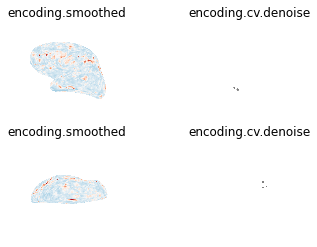

In [93]:
colorbar = False
figure, axes = plt.subplots(nrows=2, ncols=2, subplot_kw=dict(projection='3d'))

nplt.plot_surf_stat_map(surf_mesh=surf_mesh,stat_map=surf_data_e_s, colorbar = colorbar,cmap='RdBu',view='lateral',axes=axes[0,0])
axes[0,0].set(title='encoding.smoothed')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh,stat_map=surf_data_e_c_d, colorbar = colorbar,cmap='RdBu',view='lateral',axes=axes[0,1])
axes[0,1].set(title='encoding.cv.denoise')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh,stat_map=surf_data_e_s, colorbar = colorbar,cmap='RdBu',view='dorsal',axes=axes[1,0])
axes[1,0].set(title='encoding.smoothed')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh,stat_map=surf_data_e_c_d, colorbar = colorbar,cmap='RdBu',view='dorsal',axes=axes[1,1])
axes[1,1].set(title='encoding.cv.denoise')


--> encoding.cv.denoise seems weird, just use encoding.smoothed
('encoding.cv.denoise' also had min values of -inf)

In [98]:
from os import listdir

subList = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']
subList[10]

from os import listdir
subList = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']

for sub in subList[:5]:

'46'

In [102]:
subList[:5]

['13', '14', '22', '25', '49']

In [114]:
# save to .gii file
bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk' # careful, pycortex subs are referrring to fmriprep/freesurfer registration saved on local that is different to the one on /Volumes etc.
#bids_folder = '/Users/mrenke/data/ds-stressrisk'

subList = [f[4:] for f in listdir(op.join(bids_folder,'derivatives/encoding_model.smoothed')) if f[0:3] == 'sub']

for sub in subList:
    try:
        pati_r2 =  op.join(bids_folder, f'derivatives/encoding_model.smoothed/sub-{sub}/ses-1/func/') 
        pati_surf = op.join(bids_folder, f'derivatives/freesurfer/sub-{sub}/surf/')

        vol_input = op.join(pati_r2,f'sub-{sub}_ses-1_desc-r2.optim_space-T1w_pars.nii.gz' ) # files in encoding_model.smoothed were apparently all constructed before the "new" fmriprep run on sciencecluster..

        for hemi in ['lh','rh']:
            #surf_mesh = op.join(pati_surf,'lh.inflated')
            surf_inner_mesh = op.join(pati_surf,f'{hemi}.white')
            surf_pial_mesh =  op.join(pati_surf,f'{hemi}.pial')

            surf_data = surface.vol_to_surf(vol_input, surf_mesh = surf_pial_mesh, radius=3.0, interpolation='linear', kind='auto', n_samples=None, mask_img=None, inner_mesh=surf_inner_mesh, depth=None)

            gii_im = nib.gifti.gifti.GiftiImage(darrays= [nib.gifti.gifti.GiftiDataArray(data=surf_data)])
            out_file = op.join(pati_r2, f'sub-{sub}_ses-1_task-risk_space-fsnative_hemi-{hemi}_r2.surf.gii')
            gii_im.to_filename(out_file)
            print(out_file)
    except:
        print(f'sub-{sub} did not work')


/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-13/ses-1/func/sub-13_ses-1_task-risk_space-fsnative_hemi-lh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-13/ses-1/func/sub-13_ses-1_task-risk_space-fsnative_hemi-rh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-14/ses-1/func/sub-14_ses-1_task-risk_space-fsnative_hemi-lh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-14/ses-1/func/sub-14_ses-1_task-risk_space-fsnative_hemi-rh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-22/ses-1/func/sub-22_ses-1_task-risk_space-fsnative_hemi-lh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-22/ses-1/func/sub-22_ses-1_task-risk_space-fsnative_hemi-rh_r2.surf.gii
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-25/ses-1/func/sub-25_ses-1_ta

In [111]:
hemi = 'lh'
surf_inner_mesh = op.join(pati_surf,f'{hemi}.white')
surf_pial_mesh =  op.join(pati_surf,f'{hemi}.pial')
surf_data_l = surface.vol_to_surf(vol_input, surf_mesh = surf_pial_mesh, radius=3.0, interpolation='linear', kind='auto', n_samples=None, mask_img=None, inner_mesh=surf_inner_mesh, depth=None)

hemi = 'rh'
surf_inner_mesh = op.join(pati_surf,f'{hemi}.white')
surf_pial_mesh =  op.join(pati_surf,f'{hemi}.pial')
surf_data_r = surface.vol_to_surf(vol_input, surf_mesh = surf_pial_mesh, radius=3.0, interpolation='linear', kind='auto', n_samples=None, mask_img=None, inner_mesh=surf_inner_mesh, depth=None)


In [112]:
print(len(surf_data_l))
print(len(surf_data_r))
print(len(surf_data_l)+len(surf_data_r))

127664
128174
255838


In [109]:
print(len(surf_data_l))
print(len(surf_data_r))
print(len(surf_data_l)+len(surf_data_r))

128543
127879
256422


In [37]:
# visualize

import nibabel as nib
from sklearn import preprocessing
from  nilearn.datasets import fetch_surf_fsaverage

sub = '01'
space = 'fsaverage'
hemi = 'lh'

fsaverage = fetch_surf_fsaverage(mesh=space)
surf_mesh = fsaverage.infl_left if hemi == 'lh' else fsaverage.infl_right

surf_file = op.join(bids_folder,base ,f'sub-{sub}/ses-1/func/sub-{sub}_ses-1_desc-r2.optim_space-{space}_pars_hemi-{hemi}.gii')
surf_data = nib.load(surf_file).agg_data()

nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap=cmap,view='dorsal')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap=cmap,view='lateral') # '[posterior]
plt.show() # gets rid of double plotting

### check exisiting r2_space-fsnative files

in `gradent/old_scripts/vis_gradients.py` I already constructed r2_surf files with pycortex


In [45]:
bids_folder = '/Users/mrenke/data/ds-stressrisk'

sub='01'
ses=1

source_dir = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-{ses}')
r2_L = nib.load(op.join(source_dir,f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-L_r2.surf.gii'))



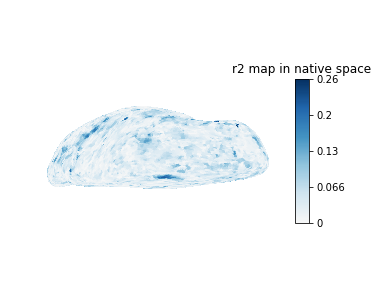

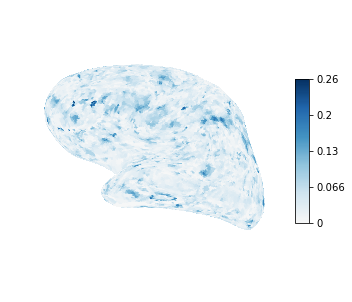

In [46]:
import nilearn.plotting as nplt

surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', 'lh.inflated') # this time use fasnative surf_mesh, not fsaver
surf_data = r2_L.agg_data()
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap='RdBu',view='dorsal')
plt.title('r2 map in native space')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap='RdBu',view='lateral')
plt.show()



### transform these now to fsaverage5 space

In [21]:
from nipype.interfaces.freesurfer import SurfaceTransform

def fsnativeTofsav(sub,in_file,  hemi = 'L', target_space = 'fsaverage5'):
    sxfm = SurfaceTransform(subjects_dir=op.join(bids_folder,'derivatives','freesurfer'))

    out_file = in_file.replace('fsnative',target_space)

    sxfm.inputs.source_file = in_file
    sxfm.inputs.out_file = out_file

    sxfm.inputs.source_subject = f'sub-{sub}'
    sxfm.inputs.target_subject = target_space

    if hemi == 'L':
        sxfm.inputs.hemi = 'lh'
    elif hemi == 'R':
        sxfm.inputs.hemi = 'rh'

    r = sxfm.run()


231113-10:39:35,695 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


In [ ]:
hemi = 'R' # put from /Users/mrenke/data/ds-stressrisk/derivatives/gradients/sub-01/ses-1 to /Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/ first!
in_file = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-01/ses-1/func/sub-01_ses-1_task-risk_space-fsnative_hemi-{hemi}_r2.surf.gii'
fsnativeTofsav(sub='01',in_file=in_file, hemi=hemi)

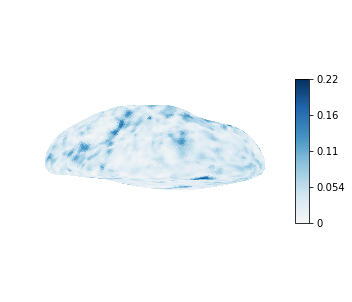

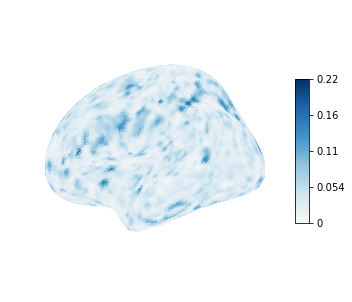

(array([3.036e+03, 4.173e+03, 1.839e+03, 7.180e+02, 3.020e+02, 1.050e+02,
        4.400e+01, 1.700e+01, 6.000e+00, 2.000e+00]),
 array([0.        , 0.02153821, 0.04307642, 0.06461462, 0.08615284,
        0.10769104, 0.12922925, 0.15076746, 0.17230567, 0.19384387,
        0.21538208], dtype=float32),
 <BarContainer object of 10 artists>)

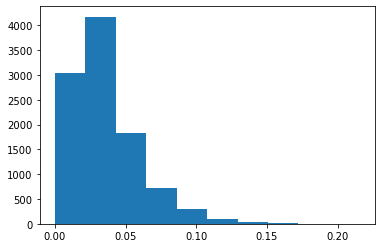

In [29]:
fsaverage = fetch_surf_fsaverage(mesh='fsaverage5')
surf_mesh = fsaverage.infl_left

surf_file_l = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-01/ses-1/func/sub-01_ses-1_task-risk_space-fsaverage5_hemi-L_r2.surf.gii'

surf = nib.load(surf_file_l)
surf_data = surf.agg_data()


nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap='RdBu',view='dorsal')
plt.title('r2 map in fsaverage space')

nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_data,cmap='RdBu',view='lateral')
plt.show()
plt.hist(surf_data)

### Difference in fsaverage5 space

In [52]:
pati = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-01/ses-1/func/'
surf_l = nib.load(op.join(pati, 'sub-01_ses-1_task-risk_space-fsaverage5_hemi-L_r2.surf.gii')).agg_data()
surf_r = nib.load(op.join(pati, 'sub-01_ses-1_task-risk_space-fsaverage5_hemi-R_r2.surf.gii')).agg_data()

surf_dif = surf_l - surf_r

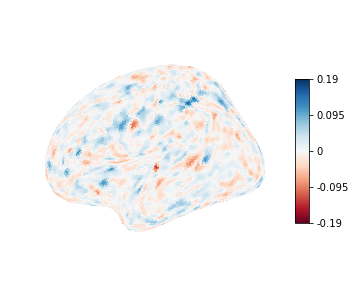

In [57]:
fsaverage = fetch_surf_fsaverage(mesh='fsaverage5')
surf_mesh = fsaverage.infl_left

nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_dif,cmap='RdBu',view='lateral')
plt.show()

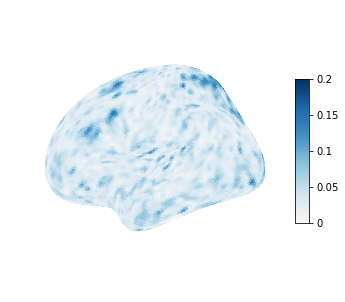

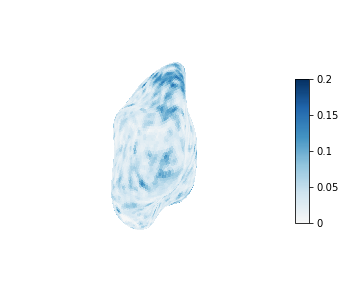

In [60]:
sub = '02'
pati = f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.smoothed/sub-{sub}/ses-1/func/'
surf_l = nib.load(op.join(pati, f'sub-{sub}_ses-1_desc-r2.optim_space-fsaverage5_pars_hemi-lh.gii')).agg_data()

nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_l,cmap='RdBu',view='lateral')
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, colorbar = True,stat_map=surf_l,cmap='RdBu',view='posterior')

plt.show()